In [1]:
import pandas as pd
import numpy as np 
import sklearn as sk
import matplotlib.pyplot as plt
import statsmodels.api as sm

Form GBM model


===== Agglomerative Cluster Features =====
Train Misclassification Rate: 25.60%
Train AUC-ROC: 82.22%
Test Misclassification Rate: 26.27%
Test AUC-ROC: 81.64%


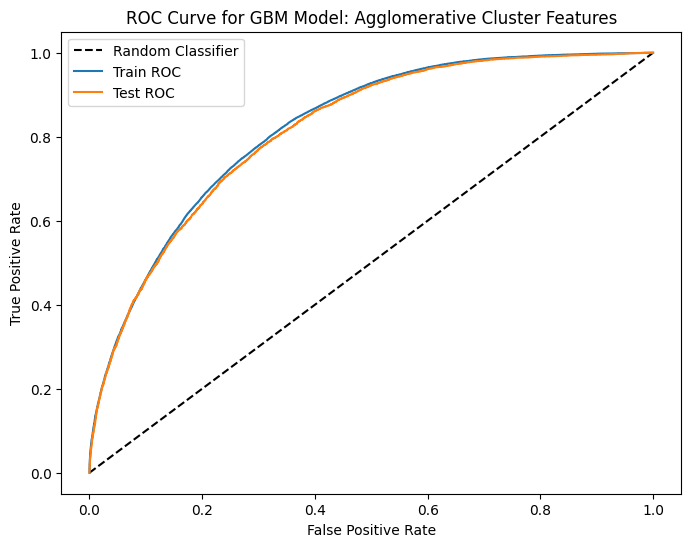


===== Original Features =====
Train Misclassification Rate: 25.10%
Train AUC-ROC: 83.15%
Test Misclassification Rate: 25.55%
Test AUC-ROC: 82.57%


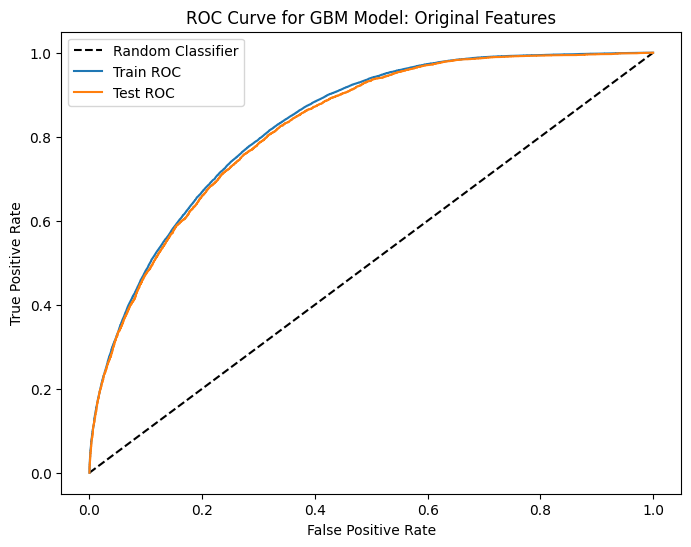


===== Independent Cluster Features =====
Train Misclassification Rate: 25.11%
Train AUC-ROC: 83.11%
Test Misclassification Rate: 25.64%
Test AUC-ROC: 82.57%


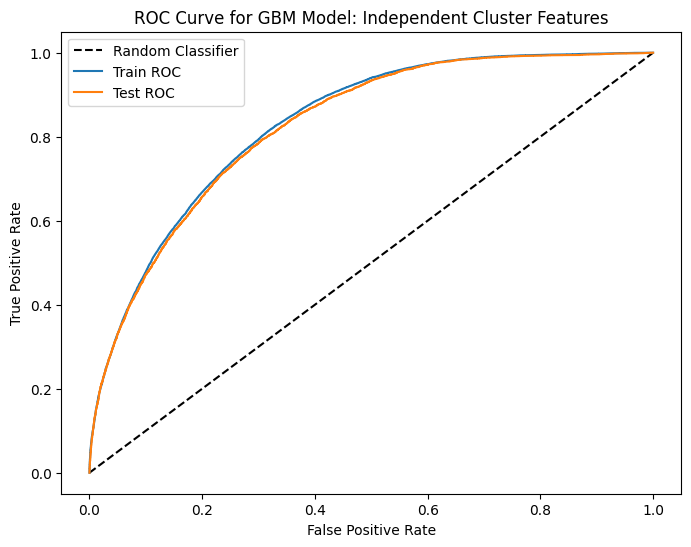

In [2]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

x_train = pd.read_csv('../data/x_train_cluster_agglom.csv')
y_train = pd.read_csv('../data/y_train.csv')
x_test = pd.read_csv('../data/x_test_cluster_agglom.csv')
y_test = pd.read_csv('../data/y_test.csv')

x_train_2 = pd.read_csv('../data/x_train.csv')
x_test_2 = pd.read_csv('../data/x_test.csv')

x_train_3 = pd.read_csv('../data/x_train_cluster_independent.csv')
x_test_3 = pd.read_csv('../data/x_test_cluster_independent.csv')

# Put each version of your training/testing data into a dictionary
datasets = {
    "Agglomerative Cluster Features": (x_train, x_test),
    "Original Features": (x_train_2, x_test_2),
    "Independent Cluster Features": (x_train_3, x_test_3)
}

# Loop through each dataset
for name, (X_train, X_test) in datasets.items():
    
    print(f"\n===== {name} =====")
    
    # Create GBM model
    gbm = GradientBoostingClassifier(
        n_estimators=50,
        learning_rate=0.1,
        max_depth=5,
        random_state=0,
        min_samples_leaf=20
    )
    
    # Fit model
    gbm.fit(X_train, y_train.values.ravel())
    
    # -------------------------
    # Training set performance
    # -------------------------
    y_train_pred = gbm.predict(X_train)
    y_train_prob = gbm.predict_proba(X_train)[:, 1]
    
    conf_matrix_train = confusion_matrix(y_train, y_train_pred)
    
    misclassify_rate_train = (
        conf_matrix_train[0][1] + conf_matrix_train[1][0]
    ) / len(y_train)
    
    auc_roc_train = roc_auc_score(y_train, y_train_prob)
    
    print(f"Train Misclassification Rate: {misclassify_rate_train:.2%}")
    print(f"Train AUC-ROC: {auc_roc_train:.2%}")
    
    # -------------------------
    # Test set performance
    # -------------------------
    y_test_pred = gbm.predict(X_test)
    y_test_prob = gbm.predict_proba(X_test)[:, 1]
    
    conf_matrix_test = confusion_matrix(y_test, y_test_pred)
    
    misclassify_rate_test = (
        conf_matrix_test[0][1] + conf_matrix_test[1][0]
    ) / len(y_test)
    
    auc_roc_test = roc_auc_score(y_test, y_test_prob)
    
    print(f"Test Misclassification Rate: {misclassify_rate_test:.2%}")
    print(f"Test AUC-ROC: {auc_roc_test:.2%}")
    
    # -------------------------
    # Plot ROC curve for train and test
    # -------------------------
    fpr_train, tpr_train, _ = roc_curve(y_train, y_train_prob)
    fpr_test, tpr_test, _ = roc_curve(y_test, y_test_prob)
    
    plt.figure(figsize=(8, 6))
    plt.plot([0, 1], [0, 1], "k--", label="Random Classifier")
    plt.plot(fpr_train, tpr_train, label="Train ROC")
    plt.plot(fpr_test, tpr_test, label="Test ROC")
    
    plt.title(f"ROC Curve for GBM Model: {name}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()